QPCA Approach with just a random x 
QPCA leverages quantum phase estimation (QPE) to find the eigenvalues and eigenvectors of the covariance matrix of your dataset. The key idea is:

Encode the covariance matrix 
Σ
Σ into a quantum state.
Apply Quantum Phase Estimation (QPE) to extract its eigenvalues.
Measure the eigenvalues, which correspond to the principal components.

In [1]:
#PIris dataset.

from sklearn.datasets import load_iris
import pandas as pd
import seaborn as sns

# Load the iris dataset as a pandas DataFrame
iris = load_iris()

# Convert the dataset to a pandas DataFrame
iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)

# Add the target column to the DataFrame, using target_names to map integers to class labels
iris_df['target'] = pd.Categorical.from_codes(iris.target, iris.target_names)

In [2]:
#make a covariance matrix 

import numpy as np

# Select only numerical features
iris_features = iris_df.iloc[:, :-1]  # Exclude target column

# Compute the covariance matrix transpose so its features not samples 4x4
cov_matrix = np.cov(iris_features.T)

# Convert to DataFrame for readability
cov_df = pd.DataFrame(cov_matrix, index=iris.feature_names, columns=iris.feature_names)

# Display the covariance matrix
print(cov_df)




                   sepal length (cm)  sepal width (cm)  petal length (cm)  \
sepal length (cm)           0.685694         -0.042434           1.274315   
sepal width (cm)           -0.042434          0.189979          -0.329656   
petal length (cm)           1.274315         -0.329656           3.116278   
petal width (cm)            0.516271         -0.121639           1.295609   

                   petal width (cm)  
sepal length (cm)          0.516271  
sepal width (cm)          -0.121639  
petal length (cm)          1.295609  
petal width (cm)           0.581006  


In [3]:
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter


In [4]:
from qiskit_algorithms.phase_estimators import HamiltonianPhaseEstimation



ModuleNotFoundError: No module named 'qiskit_algorithms'

In [322]:
from qiskit_machine_learning.utils import algorithm_globals
from qiskit.circuit.library import ZZFeatureMap
from qiskit.primitives import StatevectorSampler as Sampler
from qiskit_machine_learning.state_fidelities import ComputeUncompute
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit.compiler import transpile


In [323]:
def encode_cov_matrix(cov_df):
    """Encode covariance matrix into a quantum state"""
    qc = QuantumCircuit(4) #4 qubits for 4 features ? not sure thats right maybe use feature map function ZZFeatureMap ?
    qc.h([0, 1])  # Apply Hadamard to create superposition
    qc.cx(0, 1)   # Entangle qubits to mimic data correlation
    return qc

In [324]:
def quantum_pca():
    """Perform Quantum PCA using Phase Estimation"""
    num_qubits = 2  # Assume 2D data
    qc = QuantumCircuit(num_qubits + 1)  # Extra qubit for phase estimation
    
    # Apply QPE (simplified)
    qc.h(range(num_qubits))  # Hadamard transform
    qc.cz(0, 1)  # Controlled-Z gate to encode eigenvalues
    qc.h(range(num_qubits))  # Hadamard transform again

    return qc

In [1]:
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, plot_state_city
import qiskit.quantum_info as qi


ModuleNotFoundError: No module named 'qiskit_aer'

Covariance Matrix:
 [[0.07142857 0.00239642]
 [0.00239642 0.07142857]]
Eigenvalues (Classical PCA): [0.06903215 0.07382499]
(array([0.06903215, 0.07382499]), array([[ 0.70710678, -0.70710678],
       [-0.70710678, -0.70710678]]))
     ┌───┐   ┌───┐     ┌─┐   
q_0: ┤ H ├─■─┤ H ├─────┤M├───
     ├───┤ │ └───┘┌───┐└╥┘┌─┐
q_1: ┤ H ├─■───■──┤ H ├─╫─┤M├
     └───┘   ┌─┴─┐└┬─┬┘ ║ └╥┘
q_2: ────────┤ X ├─┤M├──╫──╫─
             └───┘ └╥┘  ║  ║ 
c: 3/═══════════════╩═══╩══╩═
                    2   0  1 
{'111': 262, '000': 253, '010': 250, '101': 259}


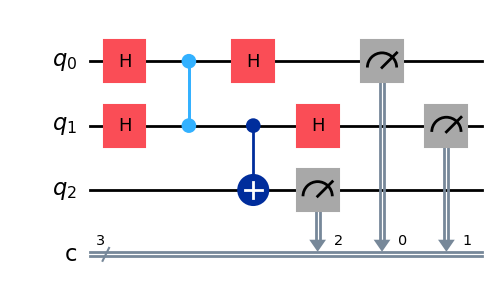

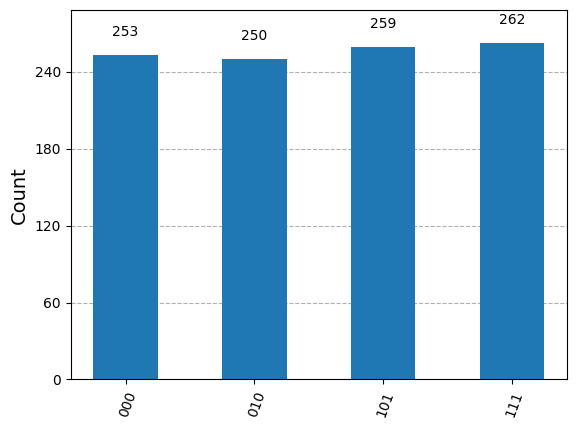

In [328]:
import numpy as np
x = [np.random.rand(15), np.random.rand(15)]
#RANDOM INPUT : Example input
%matplotlib inline


import qiskit
from qiskit import QuantumCircuit

from qiskit.compiler import transpile
from qiskit.primitives import Estimator
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector

import matplotlib.pyplot as plt

def classical_pca(x):
    """Classical PCA: Computes covariance matrix and eigenvalues"""
    x = np.array(x)
    
    # Center and normalize the data
    x[0] -= np.mean(x[0])
    x[1] -= np.mean(x[1])
    x[0] /= np.linalg.norm(x[0])
    x[1] /= np.linalg.norm(x[1])

    # Compute covariance matrix
    m = np.cov(x)  # Already unbiased
    print("Covariance Matrix:\n", m)
   
    # Compute classical eigenvalues and eigenvectors
    eigvals, eigvecs = np.linalg.eigh(m)
    print(f"Eigenvalues (Classical PCA): {eigvals}")
    return eigvals, eigvecs
   


print(classical_pca(x))


def quantum_pca():
    """Quantum PCA using Qiskit & Quantum Phase Estimation (QPE)"""

    # Define the number of qubits
    n_qubits = 3 # 2 for encoding, 1 for phase estimation
    qc = QuantumCircuit(n_qubits, n_qubits) #,1

    # Apply Hadamard gates for superposition
    qc.h(range(n_qubits - 1))

    # Controlled-unitary encoding of covariance matrix (simplified)
    qc.cz(0, 1)  # Entangle qubits
    qc.cx(1, 2)  # Simulate eigenvalue encoding

    # Quantum Phase Estimation (simplified)
    qc.h(range(n_qubits - 1))

    # Measure all qubits
    qc.measure(range(n_qubits), range(n_qubits))

    #qc.measure(2, 0)  # Measure last qubit

    return qc



print(quantum_pca())

# Simulate Quantum PCA
simulator = AerSimulator()

# Generate a PCA circuit
qc_pca = quantum_pca()
qc_pca.draw('mpl')

# Transpile and execute
compiled_circuit = transpile(qc_pca, simulator)
job = simulator.run(compiled_circuit)
result = job.result()
counts = result.get_counts()

print(counts)
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

# Plot histogram
plot_histogram(counts)
plt.show() 





In [317]:
# Normalize counts to probabilities
total_shots = sum(counts.values())
probabilities = {k: v / total_shots for k, v in counts.items()}
print("Probabilities:", probabilities)

Probabilities: {'101': 0.2880859375, '010': 0.2578125, '000': 0.2294921875, '111': 0.224609375}


In [2]:
from qiskit_ibm_provider import IBMProvider 


ModuleNotFoundError: No module named 'qiskit_ibm_provider'

https://docs.quantum.ibm.com/migration-guides/qiskit-runtime-examples#sampler-algorithm updated circuit smapling libraries for circut and ismulator set up 

Eigenvalues: [-8.58899303e-18  1.38993321e-18  5.55615162e-17  2.50177383e-01]
Eigenvectors: [[-0.54131443 -0.18445637 -0.64440969  0.50763244]
 [-0.40297333 -0.04605573  0.75618758  0.51348974]
 [ 0.65806764 -0.58141292 -0.00954713  0.47834595]
 [ 0.3339733   0.7910839  -0.11324909  0.49982271]]


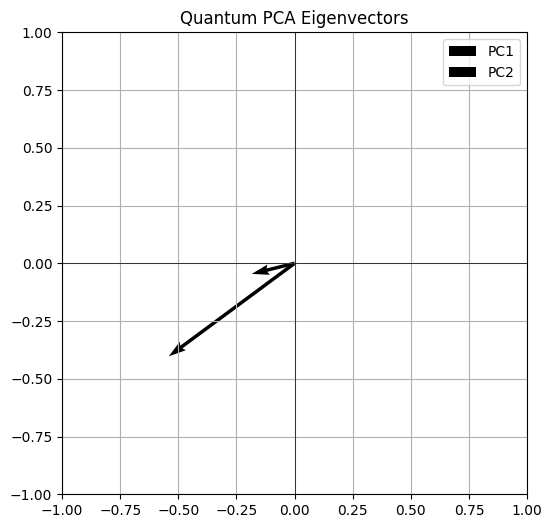

In [311]:
# Create a probability vector from the measurement probabilities
probability_vector = np.array(list(probabilities.values()))

# For simplicity, we use this probability distribution as a form of covariance matrix
cov_matrix = np.outer(probability_vector, probability_vector)

# Calculate eigenvalues and eigenvectors
eigvals, eigvecs = np.linalg.eigh(cov_matrix)

print("Eigenvalues:", eigvals)
print("Eigenvectors:", eigvecs)

# Choose the first two eigenvectors for a 2D plot (or all 4 if preferred) to comapre to the classical one? 
eigvecs_2d = eigvecs[:, :2]

# Create a quiver plot to visualize quantum PCA eigenvectors
plt.figure(figsize=(6, 6))

# Loop through each eigenvector to plot it
for i in range(eigvecs_2d.shape[1]):
    plt.quiver(0, 0, eigvecs_2d[0, i], eigvecs_2d[1, i], angles='xy', scale_units='xy', scale=1, label=f'PC{i+1}')

# Formatting the plot
plt.xlim(-1, 1)
plt.ylim(-1, 1)
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.legend()
plt.grid(True)
plt.title('Quantum PCA Eigenvectors')
plt.show()

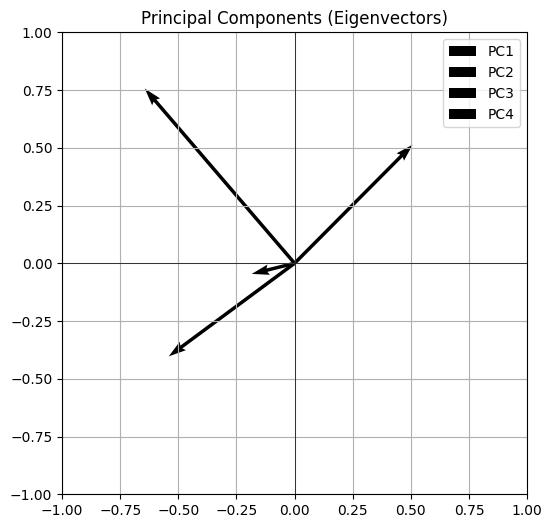

In [318]:
def plot_principal_components(eigvecs, eigvals):
    # Plot the eigenvectors (for 2D or 3D data)
    plt.figure(figsize=(6, 6))
    
    # Loop through each eigenvector to plot it
    for i in range(eigvecs.shape[1]):
        plt.quiver(0, 0, eigvecs[0, i], eigvecs[1, i], angles='xy', scale_units='xy', scale=1, label=f'PC{i+1}')
    
    # Formatting the plot
    plt.xlim(-1, 1)
    plt.ylim(-1, 1)
    plt.axhline(0, color='black',linewidth=0.5)
    plt.axvline(0, color='black',linewidth=0.5)
    plt.legend()
    plt.grid(True)
    plt.title('Principal Components (Eigenvectors)')
    plt.show()

plot_principal_components(eigvecs, eigvals)


In [319]:
# Perform classical PCA
classical_eigvals, classical_eigvecs = classical_pca(x)

print(f"eigvals: {classical_eigvals}")
print(f"eigvecs: {classical_eigvecs}")

Covariance Matrix:
 [[0.07142857 0.00741305]
 [0.00741305 0.07142857]]
Eigenvalues (Classical PCA): [0.06401553 0.07884162]
eigvals: [0.06401553 0.07884162]
eigvecs: [[-0.70710678  0.70710678]
 [ 0.70710678  0.70710678]]


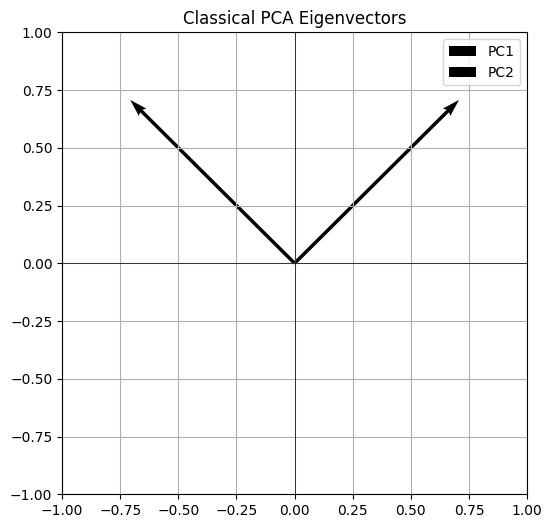

In [320]:
# Plot Classical Eigenvectors
plt.figure(figsize=(6, 6))
for i in range(classical_eigvecs.shape[1]):
    plt.quiver(0, 0, classical_eigvecs[0, i], classical_eigvecs[1, i], angles='xy', scale_units='xy', scale=1, label=f'PC{i+1}')
plt.xlim(-1, 1)
plt.ylim(-1, 1)
plt.axhline(0, color='black',linewidth=0.5)
plt.axvline(0, color='black',linewidth=0.5)
plt.legend()
plt.grid(True)
plt.title('Classical PCA Eigenvectors')
plt.show()

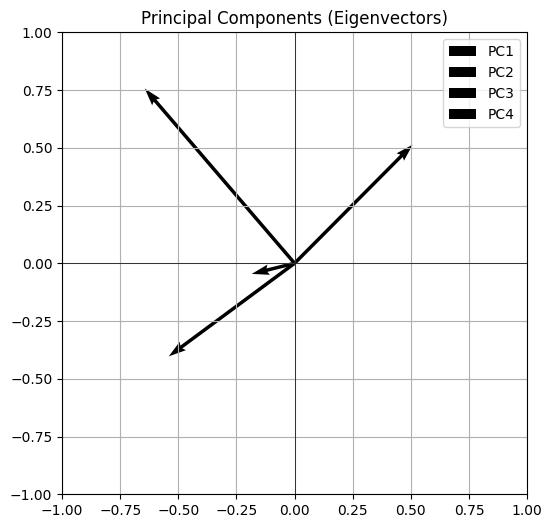

In [312]:
plot_principal_components(eigvecs, eigvals)


In [313]:
# Convert counts to probabilities
shots = sum(counts.values())
P_0 = counts.get('0', 0) / shots
P_1 = counts.get('1', 0) / shots

# Compute expectation value
E_Z = P_0 - P_1
print("Expectation value <Z>:", E_Z)


Expectation value <Z>: 0.0
